In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

In [2]:
test = pd.read_csv('/kaggle/input/playground-series-s4e8/test.csv')
test.head()

,id,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,3116945,8.64,x,NaN,n,t,NaN,NaN,w,11.13,17.12,b,NaN,w,u,w,t,g,NaN,d,a
1,3116946,6.90,o,t,o,f,NaN,c,y,1.27,10.75,NaN,NaN,n,NaN,NaN,f,f,NaN,d,a
2,3116947,2.00,b,g,n,f,NaN,c,n,6.18,3.14,NaN,NaN,n,NaN,NaN,f,f,NaN,d,s
3,3116948,3.47,x,t,n,f,s,c,n,4.98,8.51,NaN,NaN,w,NaN,n,t,z,NaN,d,u
4,3116949,6.17,x,h,y,f,p,NaN,y,6.73,13.70,NaN,NaN,y,NaN,y,t,NaN,NaN,d,u


In [3]:
train = pd.read_csv('/kaggle/input/playground-series-s4e8/train.csv')
train.head() 

,id,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,0,e,8.80,f,s,u,f,a,c,w,4.51,15.39,NaN,NaN,w,NaN,NaN,f,f,NaN,d,a
1,1,p,4.51,x,h,o,f,a,c,n,4.79,6.48,NaN,y,o,NaN,NaN,t,z,NaN,d,w
2,2,e,6.94,f,s,b,f,x,c,w,6.85,9.93,NaN,s,n,NaN,NaN,f,f,NaN,l,w
3,3,e,3.88,f,y,g,f,s,NaN,g,4.16,6.53,NaN,NaN,w,NaN,NaN,f,f,NaN,d,u
4,4,e,5.85,x,l,w,f,d,NaN,w,3.37,8.36,NaN,NaN,w,NaN,NaN,f,f,NaN,g,a


In [4]:
combined = pd.concat([train,test])
combined.head() 

,id,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,0,e,8.80,f,s,u,f,a,c,w,4.51,15.39,NaN,NaN,w,NaN,NaN,f,f,NaN,d,a
1,1,p,4.51,x,h,o,f,a,c,n,4.79,6.48,NaN,y,o,NaN,NaN,t,z,NaN,d,w
2,2,e,6.94,f,s,b,f,x,c,w,6.85,9.93,NaN,s,n,NaN,NaN,f,f,NaN,l,w
3,3,e,3.88,f,y,g,f,s,NaN,g,4.16,6.53,NaN,NaN,w,NaN,NaN,f,f,NaN,d,u
4,4,e,5.85,x,l,w,f,d,NaN,w,3.37,8.36,NaN,NaN,w,NaN,NaN,f,f,NaN,g,a


In [12]:
rows, cols = combined.shape
print(F"Number of rows: {rows}")
print(F"Number of columns: {cols}")

def variable_type(col):
    if combined[col].dtype == 'object':
        return 'Categorical'
    elif df[col].nunique() / rows < 0.05:
        return ' Categorical'
    else:
        return 'Continous'
variable_type = combined.columns.to_series().apply(variable_type)
print("Variable Types:\n", variable_type)

Number of rows: 5194909
Number of columns: 22
Variable Types:
 id                         Continous
class                    Categorical
cap-diameter             Categorical
cap-shape                Categorical
cap-surface              Categorical
cap-color                Categorical
does-bruise-or-bleed     Categorical
gill-attachment          Categorical
gill-spacing             Categorical
gill-color               Categorical
stem-height              Categorical
stem-width               Categorical
stem-root                Categorical
stem-surface             Categorical
stem-color               Categorical
veil-type                Categorical
veil-color               Categorical
has-ring                 Categorical
ring-type                Categorical
spore-print-color        Categorical
habitat                  Categorical
season                   Categorical
dtype: object


In [9]:
numerical_columns = combined.select_dtypes(include='number')

five_point_summary = numerical_columns.describe(percentiles=[0.25,0.5,0.75]).loc[['min','25%','50%','75%','max']]
print("Five-point summary:\n", five_point_summary)

Five-point summary:
             id  cap-diameter  stem-height  stem-width
min        0.0          0.00         0.00        0.00
25%  1298727.0          3.32         4.67        4.97
50%  2597454.0          5.74         5.88        9.65
75%  3896181.0          8.24         7.41       15.62
max  5194908.0        607.00        88.72      102.91


In [11]:
categorical_columns = combined.select_dtypes(include='object')
def summarize_categorical (column):
    count = column.value_counts()
    Percentage = column.value_counts(normalize=True)*100
    summary = pd.DataFrame({"Count": count, 'Percentage': Percentage})
    return summary

categorical_summary = {col: summarize_categorical(combined[col]) for col in categorical_columns}

for col, summary in categorical_summary.items():
    print(F"Summary for {col}:\n{summary}\n")
    

Summary for class:
         Count  Percentage
class                     
p      1705396   54.713702
e      1411549   45.286298

Summary for cap-shape:
             Count  Percentage
cap-shape                     
x          2393975   46.083728
f          1128598   21.725374
s           607844   11.700923
b           530525   10.212542
o           180807    3.480513
...            ...         ...
3.25             1    0.000019
3.37             1    0.000019
1.66             1    0.000019
9.13             1    0.000019
4.54             1    0.000019

[108 rows x 2 columns]

Summary for cap-surface:
              Count  Percentage
cap-surface                    
t            767629   18.828364
s            642160   15.750867
y            546162   13.396233
h            474197   11.631079
g            439869   10.789084
...             ...         ...
14.04             1    0.000025
8.96              1    0.000025
10.83             1    0.000025
has h             1    0.000025
5.1         

In [23]:
missing_values = combined.isnull().sum()
missing_percentage = (combined.isnull().sum() /len(combined))*100
missing_data_summary = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
print("Missing values summary:\n", missing_data_summary)

def detect_outliers(combined):
    outliers = pd.DataFrame(columns=combined.columns)
    for col in combined.select_dtypes(include=np.number).columns:
        Q1 = combined[col].quantile(0.25)
        Q3 = combined[col].quantile(0.75)
        IQR = Q3-Q1
        lower_bound = Q1 - 1.5*IQR
        upper_bound = Q3 + 1.5*IQR
        outlier_condition = (combined[col] < lower_bound)| (combined[col] > upper_bound)
        outliers[col] = outlier_condition
    return outliers

outliers = detect_outliers(combined)
outliers_summary = outliers.sum()
print("Outliers Summary:\n", outliers_summary)

class_counts = combined['cap-diameter'].value_counts()
class_percentage = combined['cap-diameter'].value_counts(normalize=True)*100
class_imbalance_summary = pd.DataFrame({'Count': class_counts, 'Percenatge': class_percentage})
print("Class Imbalbance summary:\n", class_imbalance_summary)
        

Missing values summary:
                       Missing Values  Percentage
id                                 0    0.000000
class                        2077964   40.000008
cap-diameter                      11    0.000212
cap-shape                         71    0.001367
cap-surface                  1117927   21.519665
cap-color                         25    0.000481
does-bruise-or-bleed              18    0.000346
gill-attachment               873757   16.819486
gill-spacing                 2098030   40.386270
gill-color                       106    0.002040
stem-height                        1    0.000019
stem-width                         0    0.000000
stem-root                    4595035   88.452656
stem-surface                 3302349   63.568948
stem-color                        59    0.001136
veil-type                    4929038   94.882086
veil-color                   4567071   87.914360
has-ring                          43    0.000828
ring-type                     215075    4.14

In [12]:
combined.head()

,id,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,0.0,e,8.80,f,s,u,f,a,c,w,4.51,15.39,NaN,NaN,w,NaN,NaN,f,f,NaN,d,a
1,1.0,p,4.51,x,h,o,f,a,c,n,4.79,6.48,NaN,y,o,NaN,NaN,t,z,NaN,d,w
2,2.0,e,6.94,f,s,b,f,x,c,w,6.85,9.93,NaN,s,n,NaN,NaN,f,f,NaN,l,w
3,3.0,e,3.88,f,y,g,f,s,NaN,g,4.16,6.53,NaN,NaN,w,NaN,NaN,f,f,NaN,d,u
4,4.0,e,5.85,x,l,w,f,d,NaN,w,3.37,8.36,NaN,NaN,w,NaN,NaN,f,f,NaN,g,a


In [5]:
combined.dtypes

id                        int64
class                    object
cap-diameter            float64
cap-shape                object
cap-surface              object
cap-color                object
does-bruise-or-bleed     object
gill-attachment          object
gill-spacing             object
gill-color               object
stem-height             float64
stem-width              float64
stem-root                object
stem-surface             object
stem-color               object
veil-type                object
veil-color               object
has-ring                 object
ring-type                object
spore-print-color        object
habitat                  object
season                   object
dtype: object

In [7]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5194909 entries, 0 to 2077963
Data columns (total 22 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   class                 object 
 2   cap-diameter          float64
 3   cap-shape             object 
 4   cap-surface           object 
 5   cap-color             object 
 6   does-bruise-or-bleed  object 
 7   gill-attachment       object 
 8   gill-spacing          object 
 9   gill-color            object 
 10  stem-height           float64
 11  stem-width            float64
 12  stem-root             object 
 13  stem-surface          object 
 14  stem-color            object 
 15  veil-type             object 
 16  veil-color            object 
 17  has-ring              object 
 18  ring-type             object 
 19  spore-print-color     object 
 20  habitat               object 
 21  season                object 
dtypes: float64(3), int64(1), object(18)
memory usag

In [8]:
combined.columns

Index(['id', 'class', 'cap-diameter', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
       'stem-height', 'stem-width', 'stem-root', 'stem-surface', 'stem-color',
       'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color',
       'habitat', 'season'],
      dtype='object')

In [9]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
id,5194909.0,2.597454e+06,1.499641e+06,0.0,1298727.00,2597454.00,3896181.00,5194908.00
cap-diameter,5194898.0,6.308386e+00,4.668963e+00,0.0,3.32,5.74,8.24,607.00
stem-height,5194908.0,6.347604e+00,2.699444e+00,0.0,4.67,5.88,7.41,88.72
stem-width,5194909.0,1.115162e+01,8.097359e+00,0.0,4.97,9.65,15.62,102.91


In [11]:
combined.isnull().notnull()//len(combined*50)

,id,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2077959,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2077960,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2077961,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2077962,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [14]:
combined.corr

<bound method DataFrame.corr of               id class  cap-diameter cap-shape cap-surface cap-color  \
0              0     e          8.80         f           s         u   
1              1     p          4.51         x           h         o   
2              2     e          6.94         f           s         b   
3              3     e          3.88         f           y         g   
4              4     e          5.85         x           l         w   
...          ...   ...           ...       ...         ...       ...   
2077959  5194904   NaN          0.88         x           g         w   
2077960  5194905   NaN          3.12         x           s         w   
2077961  5194906   NaN          5.73         x           e         e   
2077962  5194907   NaN          5.03         b           g         n   
2077963  5194908   NaN         15.51         f         NaN         w   

        does-bruise-or-bleed gill-attachment gill-spacing gill-color  \
0                          f   

In [15]:
combined.shape

(5194909, 22)

<Axes: >

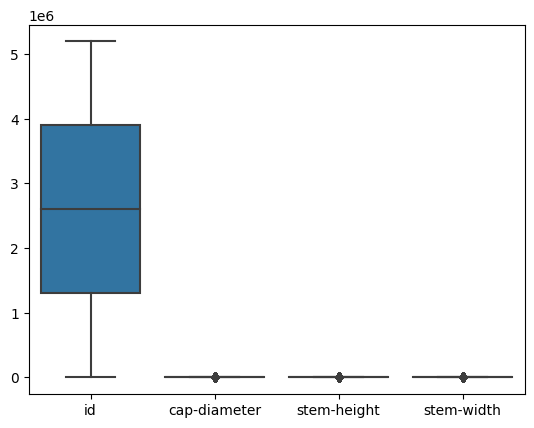

In [19]:
sns.boxplot(combined)

<Axes: >

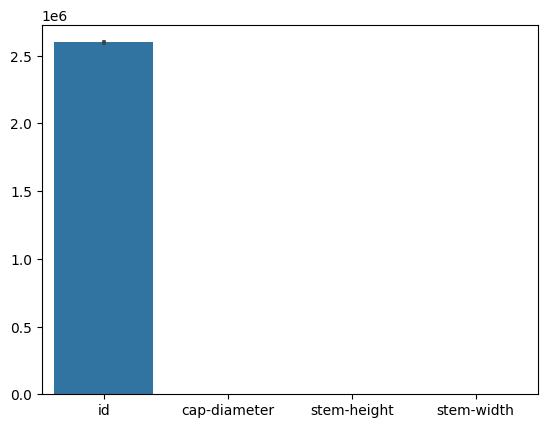

In [21]:
sns.barplot(combined)

<Axes: >

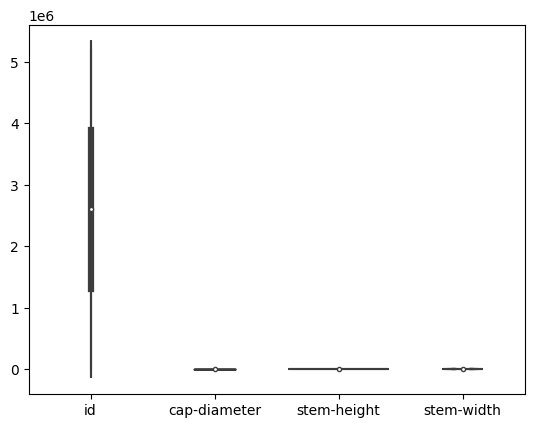

In [22]:
sns.violinplot(combined)

In [5]:
cat_cols = combined.select_dtypes(include='object')

In [6]:
for i in cat_cols:
    print(i)
    (combined[i].value_counts())
    print('\n')
    print(''*50)

class



cap-shape



cap-surface



cap-color



does-bruise-or-bleed



gill-attachment



gill-spacing



gill-color



stem-root



stem-surface



stem-color



veil-type



veil-color



has-ring



ring-type



spore-print-color



habitat



season





In [7]:
num_cols = combined.select_dtypes(include='number')

In [8]:
for i in num_cols:
    print(i)
    (combined[i].value_counts())
    print('\n')
    print(''*50)

id



cap-diameter



stem-height



stem-width





In [ ]:
plt.figure(figszie=(12,10))
sns.boxplot(data=combined,palette='mako');
plt.xticks(rotation=45);
plt.show()

In [ ]:
sns.kdeplot(data=combined,palette='mako');
plt.xticks(rotation=90)
plt.show()

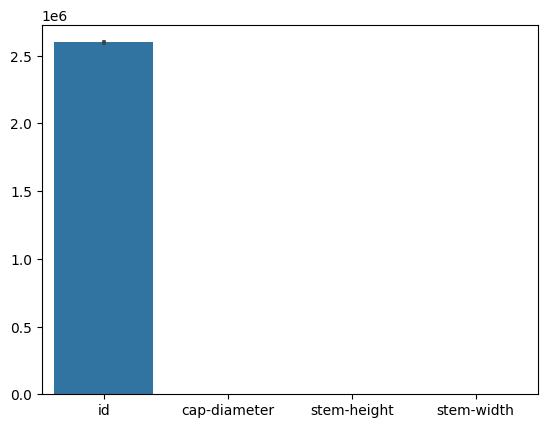

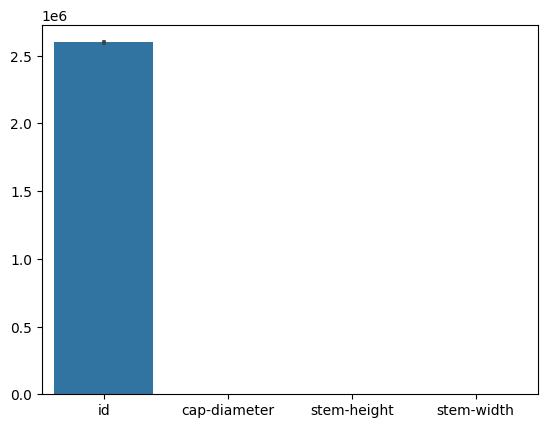

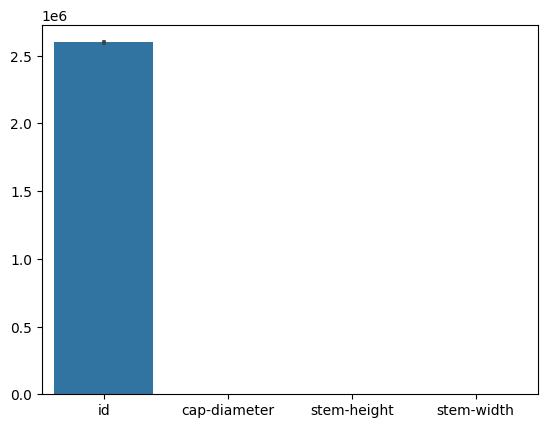

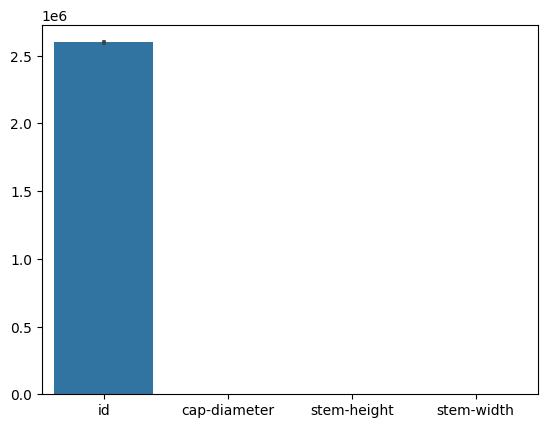

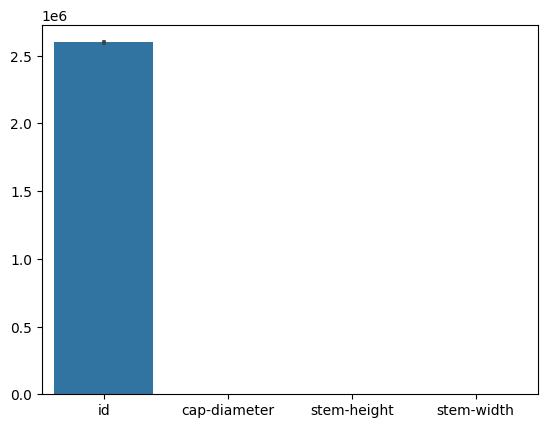

In [ ]:
x = 1
cat_cols = combined.select_dtypes(include='object')
for i in cat_cols:
    sns.barplot(data=combined)
    print('\n')
    plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

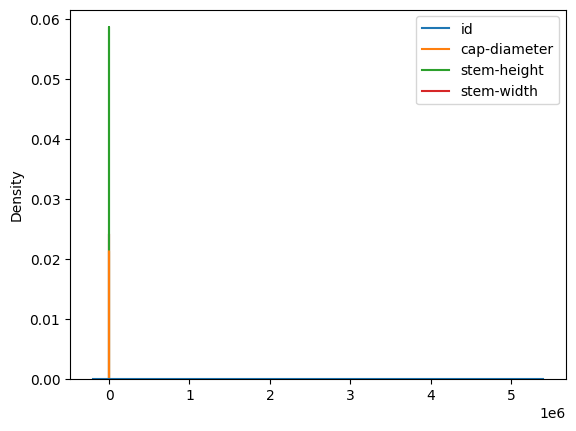

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

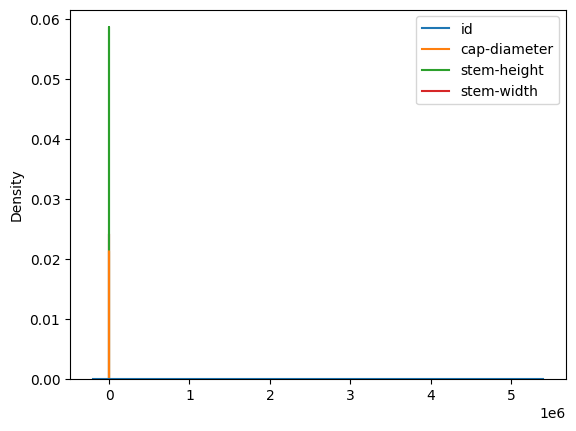

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

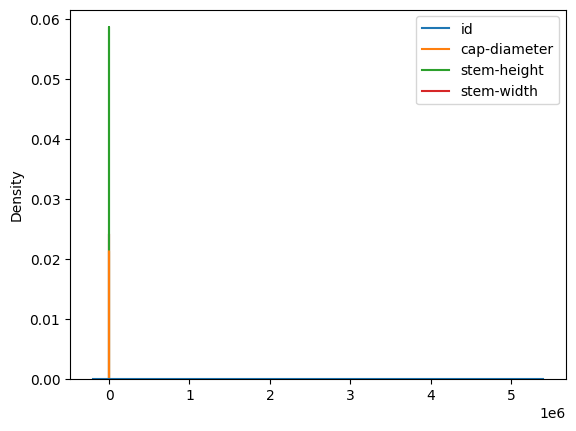

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

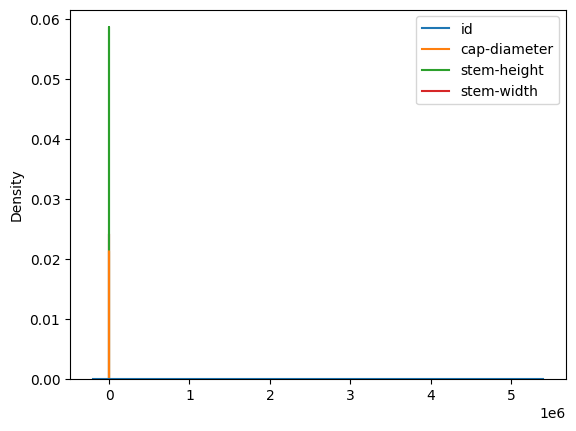

In [10]:
x = 1
num_cols = combined.select_dtypes(include='number')
for i in num_cols:
    sns.kdeplot(data=combined)
    print('\n')
    plt.show() 